# House Price Prediction — Regression Model Comparison

**Goal:** Predict `House_Price` from house features, and compare four regression models (Linear Regression, Decision Tree, KNN, Random Forest) to find the best fit for this dataset.

**Dataset:** House Price Regression Dataset (Kaggle) — 1000 rows, 8 columns, no missing values.


In [1]:
# ------------------------------------------------------------
# 1. Imports
# ------------------------------------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import joblib

RANDOM_STATE = 42  # fixed for reproducibility across the whole notebook

## 2. Data Loading

In [2]:
df = pd.read_csv('house_price_regression_dataset.csv')

print("Shape:", df.shape)
df.head()

Shape: (1000, 8)


,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
0,1360,2,1,1981,0.599637,0,5,2.623829e+05
1,4272,3,3,2016,4.753014,1,6,9.852609e+05
2,3592,1,2,2016,3.634823,0,9,7.779774e+05
3,966,1,2,1977,2.730667,1,8,2.296989e+05
4,4926,2,1,1993,4.699073,0,8,1.041741e+06


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Square_Footage        1000 non-null   int64  
 1   Num_Bedrooms          1000 non-null   int64  
 2   Num_Bathrooms         1000 non-null   int64  
 3   Year_Built            1000 non-null   int64  
 4   Lot_Size              1000 non-null   float64
 5   Garage_Size           1000 non-null   int64  
 6   Neighborhood_Quality  1000 non-null   int64  
 7   House_Price           1000 non-null   float64
dtypes: float64(2), int64(6)
memory usage: 62.6 KB


In [4]:
df.describe()

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1.000000e+03
mean,2815.422000,2.990000,1.973000,1986.550000,2.778087,1.022000,5.615000,6.188610e+05
std,1255.514921,1.427564,0.820332,20.632916,1.297903,0.814973,2.887059,2.535681e+05
min,503.000000,1.000000,1.000000,1950.000000,0.506058,0.000000,1.000000,1.116269e+05
25%,1749.500000,2.000000,1.000000,1969.000000,1.665946,0.000000,3.000000,4.016482e+05
50%,2862.500000,3.000000,2.000000,1986.000000,2.809740,1.000000,6.000000,6.282673e+05
75%,3849.500000,4.000000,3.000000,2004.250000,3.923317,2.000000,8.000000,8.271413e+05
max,4999.000000,5.000000,3.000000,2022.000000,4.989303,2.000000,10.000000,1.108237e+06


## 3. Exploratory Data Analysis (EDA)

Check correlation between each feature and the target (`House_Price`) to understand
which features actually matter before choosing a model.

In [5]:
correlation = df.corr()
print(correlation['House_Price'].sort_values(ascending=False))

House_Price             1.000000
Square_Footage          0.991261
Lot_Size                0.160412
Garage_Size             0.052133
Year_Built              0.051967
Num_Bedrooms            0.014633
Num_Bathrooms          -0.001862
Neighborhood_Quality   -0.007770
Name: House_Price, dtype: float64


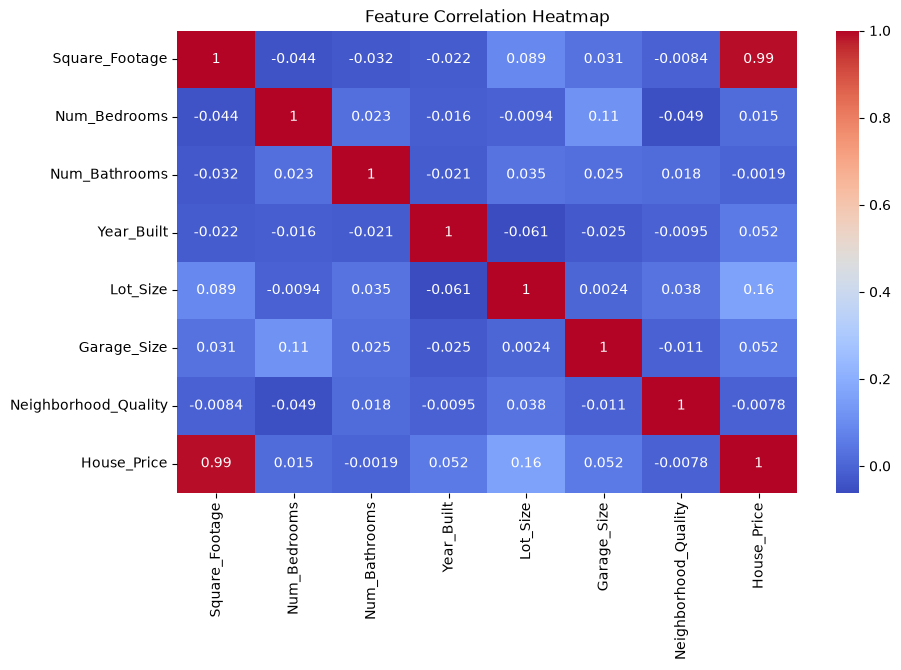

In [6]:
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.show()

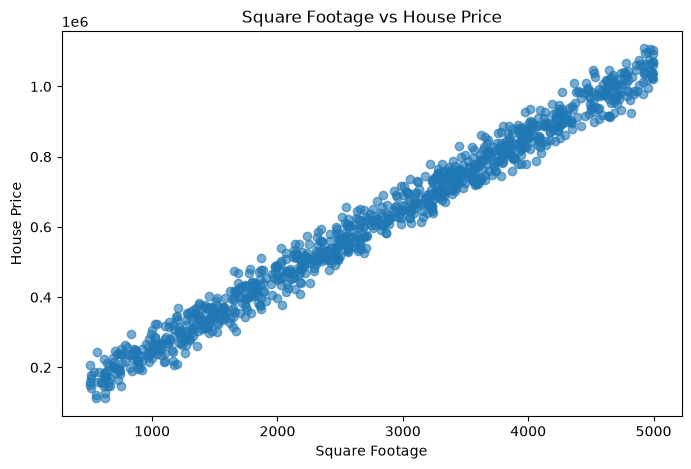

In [7]:
plt.figure(figsize=(8, 5))
plt.scatter(df['Square_Footage'], df['House_Price'], alpha=0.6)
plt.xlabel('Square Footage')
plt.ylabel('House Price')
plt.title('Square Footage vs House Price')
plt.show()

**Observation:** `Square_Footage` has a correlation of ~0.99 with `House_Price`, and the
scatter plot shows a clear linear pattern. Every other feature has weak correlation (<0.2).
This tells us upfront that a linear model is likely to perform very well here — a professional
always checks this *before* picking a model, rather than jumping straight into modeling.

## 4. Train-Test Split

In [8]:
X = df[['Square_Footage']]   # using the one feature that actually matters
y = df['House_Price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

print("Train shape:", X_train.shape, "| Test shape:", X_test.shape)

Train shape: (800, 1) | Test shape: (200, 1)


## 5. Feature Scaling

Only needed for distance-based models like KNN. Linear Regression, Decision Tree, and
Random Forest don't require it, so we scale separately and only where it's needed.

In [9]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 6. Reusable Evaluation Function

Instead of repeating the same fit → predict → evaluate code for every model (which is
messy and error-prone), we wrap it in one function. This is the DRY principle
(Don't Repeat Yourself) — a basic expectation in professional code.

In [10]:
results = []  # will hold a summary row per model

def evaluate_model(model, X_tr, X_te, y_tr, y_te, name):
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)

    mae = mean_absolute_error(y_te, y_pred)
    rmse = np.sqrt(mean_squared_error(y_te, y_pred))
    r2 = r2_score(y_te, y_pred)

    # overfitting check: compare train vs test R²
    train_r2 = model.score(X_tr, y_tr)

    results.append({
        'Model': name,
        'MAE': round(mae, 2),
        'RMSE': round(rmse, 2),
        'Test R2': round(r2, 4),
        'Train R2': round(train_r2, 4)
    })

    print(f"{name:18s} -> MAE: {mae:,.2f} | RMSE: {rmse:,.2f} | "
          f"Train R2: {train_r2:.4f} | Test R2: {r2:.4f}")

    return model, y_pred

## 7. Train & Evaluate All Four Models

In [11]:
lr_model, lr_pred = evaluate_model(
    LinearRegression(), X_train, X_test, y_train, y_test, "Linear Regression"
)

Linear Regression  -> MAE: 27,179.53 | RMSE: 32,885.95 | Train R2: 0.9824 | Test R2: 0.9832


In [12]:
dt_model, dt_pred = evaluate_model(
    DecisionTreeRegressor(random_state=RANDOM_STATE),
    X_train, X_test, y_train, y_test, "Decision Tree"
)

Decision Tree      -> MAE: 36,676.98 | RMSE: 46,488.95 | Train R2: 0.9983 | Test R2: 0.9665


In [13]:
knn_model, knn_pred = evaluate_model(
    KNeighborsRegressor(n_neighbors=5),
    X_train_scaled, X_test_scaled, y_train, y_test, "KNN"
)

KNN                -> MAE: 29,118.66 | RMSE: 36,030.89 | Train R2: 0.9858 | Test R2: 0.9799


In [14]:
rf_model, rf_pred = evaluate_model(
    RandomForestRegressor(n_estimators=100, random_state=RANDOM_STATE),
    X_train, X_test, y_train, y_test, "Random Forest"
)

Random Forest      -> MAE: 32,452.33 | RMSE: 40,851.26 | Train R2: 0.9952 | Test R2: 0.9741


## 8. Model Comparison Table

A clean summary table is what a professional keeps as an "experiment log" — it's the
evidence used to justify which model gets chosen.

In [15]:
results_df = pd.DataFrame(results).sort_values(by='Test R2', ascending=False).reset_index(drop=True)
results_df

,Model,MAE,RMSE,Test R2,Train R2
0,Linear Regression,27179.53,32885.95,0.9832,0.9824
1,KNN,29118.66,36030.89,0.9799,0.9858
2,Random Forest,32452.33,40851.26,0.9741,0.9952
3,Decision Tree,36676.98,46488.95,0.9665,0.9983


**Reading the table:**
- If `Train R2` is much higher than `Test R2`, that model is overfitting.
- The model with the highest `Test R2` (and reasonably close `Train R2`) is the best generalizer — not just the best memorizer.

## 9. Cross-Validation (Sanity Check)

A single train-test split can be lucky or unlucky. Cross-validation checks the winning
model's performance across 5 different splits, so the conclusion isn't based on chance.

In [16]:
cv_scores = cross_val_score(LinearRegression(), X, y, cv=5, scoring='r2')
print("Cross-validation R2 scores:", cv_scores)
print("Average R2 across folds:", round(cv_scores.mean(), 4))

Cross-validation R2 scores: [0.97958894 0.98118062 0.98555201 0.982874   0.98338724]
Average R2 across folds: 0.9825


## 10. Conclusion

Based on the comparison table and cross-validation, **Linear Regression** is the best model
for this dataset — because the relationship between `Square_Footage` and `House_Price` is
genuinely linear (correlation ~0.99). More complex models (Decision Tree, Random Forest)
don't add value here and, in Decision Tree's case, perform worse due to unnecessary complexity
on a simple relationship.

**Key professional takeaway:** the right model is decided by the *data's shape*, not by which
model is trendiest or most complex.

## 11. Save the Final Model (Production Step)

In [17]:
joblib.dump(lr_model, 'house_price_model.pkl')
print("Model saved as house_price_model.pkl")

# To reload later:
# loaded_model = joblib.load('house_price_model.pkl')

Model saved as house_price_model.pkl
